# Long-Only Equity Momentum: Cross-Sectional & Time-Series

**Universe / data.** iShares Core S&P 500 ETF (IVV) *monthly holdings snapshots*
scraped by [riazarbi/sp500-scraper](https://github.com/riazarbi/sp500-scraper).
Each snapshot lists every holding with its market `price`, so stacking ~20 years
of snapshots gives a **point-in-time price panel**. Because we use the *actual*
historical constituents, the universe is **survivorship-bias-free**. We keep only
`asset_class == "Equity"` rows; `market_value` is the liquidity proxy for the
capacity model. (The scraper switched to *daily* snapshots in late-2022, which
enables the weekly-rebalance study in §9.)

**Two strategies (long-only, monthly rebalance, ~15% vol target).**
* **Cross-sectional (XS)** — rank by risk-adjusted 12-1 momentum, hold the top
  quantile (*relative* strength).
* **Time-series (TS)** — hold names with positive own momentum; invested
  fraction = trend breadth, rest in cash (*absolute* / trend, self-de-risking).

**Contents.** §1 data · §2 Information Coefficient (proof of signal) ·
§3 cross-sectional · §4 time-series · **§5 portfolio weights output** ·
§6 walk-forward validation · **§7 transaction-cost-aware turnover penalty** ·
**§8 weekly-rebalance exploration** · §9 consolidated metrics · §10 conclusions.
All logic lives in `momentum_strategies.py`; outputs are saved under `results/`.

> **Headline.** Raw price momentum has weak IC in large caps; **risk-adjusting**
> doubles it (significant at the 6-month horizon). Both strategies target ~15%
> vol and are validated out-of-sample. A cost-aware turnover penalty cuts
> turnover ~30–60% with neutral-to-positive net-Sharpe impact (clearly positive
> at weekly frequency, where trading costs bite harder).

In [1]:
import warnings, os; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import momentum_strategies as ms

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 40)
DATA_DIR = "data"
FIG, FDATA, MET, WTS = "results/figures", "results/figure_data", "results/metrics", "results/weights"
for d in (FIG, FDATA, MET, WTS): os.makedirs(d, exist_ok=True)
print("module loaded:", ms.__name__)

module loaded: momentum_strategies


## 1. Data — build the point-in-time panels

`DataLoader` parses every snapshot, filters to equities, collapses to month-end,
builds the price panel and computes **split-cleaned** returns (iShares prices are
*un-adjusted*, so splits are detected via the `shares` column and de-split).

In [2]:
md = ms.DataLoader(DATA_DIR).load()
print(pd.Series(md.summary()).to_string())

start                  2006-10-31
end                    2026-06-30
n_months                      231
n_unique_names               1046
avg_names_per_month      502.4675
min_names_per_month           499
max_names_per_month           507


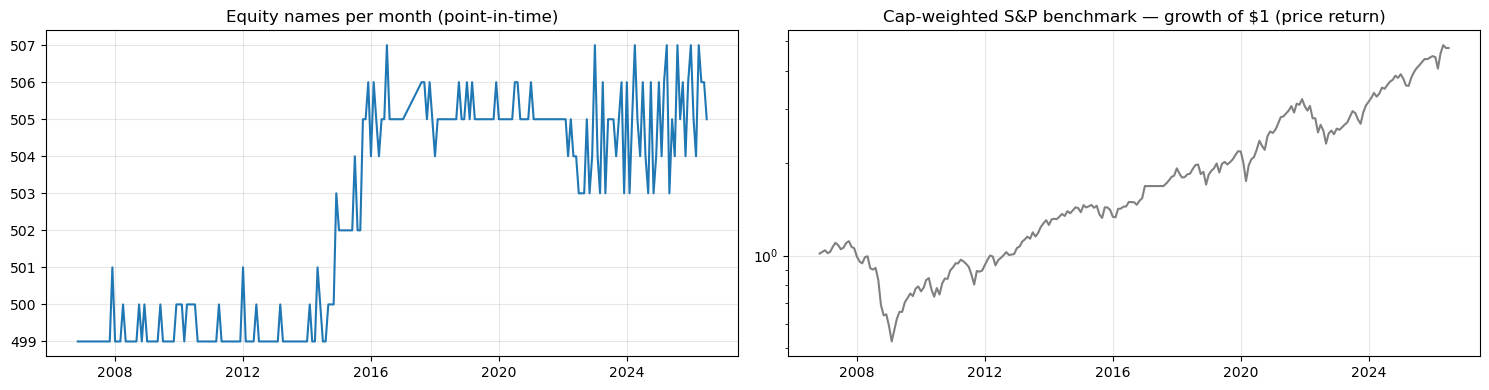

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
n_names = md.prices.notna().sum(axis=1)
ax[0].plot(n_names.index, n_names.values); ax[0].set_title("Equity names per month (point-in-time)"); ax[0].grid(alpha=0.3)
beq = (1 + md.benchmark.fillna(0)).cumprod()
ax[1].plot(beq.index, beq.values, color="grey"); ax[1].set_yscale("log")
ax[1].set_title("Cap-weighted S&P benchmark — growth of $1 (price return)"); ax[1].grid(alpha=0.3)
pd.DataFrame({"n_names": n_names, "benchmark_ret": md.benchmark, "benchmark_equity": beq}).to_csv(f"{FDATA}/data_overview.csv")
plt.tight_layout(); plt.show()

## 2. Proving the signal — Information Coefficient

The **IC** is the cross-sectional rank correlation between the signal at *t* and
the *forward* return. We compare raw 12-1 momentum, risk-adjusted 12-1 (÷ trailing
vol) and a blended 3/6/12m composite, across horizons, with the decile sort.

In [4]:
xs_cfg, ts_cfg = ms.DEFAULT_XS, ms.DEFAULT_TS
sig_raw   = ms.momentum_signal(md.prices, 12, 1, risk_adjusted=False)
sig_ra    = ms.build_signal(md, xs_cfg)
sig_blend = ms.blended_momentum_signal(md.prices, md.returns, (3, 6, 12))
signals = {"raw 12-1": sig_raw, "risk-adj 12-1": sig_ra, "blended 3/6/12": sig_blend}
ic_summary = pd.DataFrame({
    name: {k: ms.information_coefficient(s, md.returns)[k]
           for k in ("mean_ic", "ic_ir", "t_stat", "p_value", "hit_rate", "n_months")}
    for name, s in signals.items()}).T
print("Mean monthly rank-IC vs 1-month forward return:"); display(ic_summary)

Mean monthly rank-IC vs 1-month forward return:


,mean_ic,ic_ir,t_stat,p_value,hit_rate,n_months
raw 12-1,0.0102,0.0514,0.7587,0.4488,0.5321,218.0000
risk-adj 12-1,0.0152,0.0805,1.1888,0.2358,0.5459,218.0000
blended 3/6/12,0.0048,0.0259,0.3821,0.7027,0.5183,218.0000


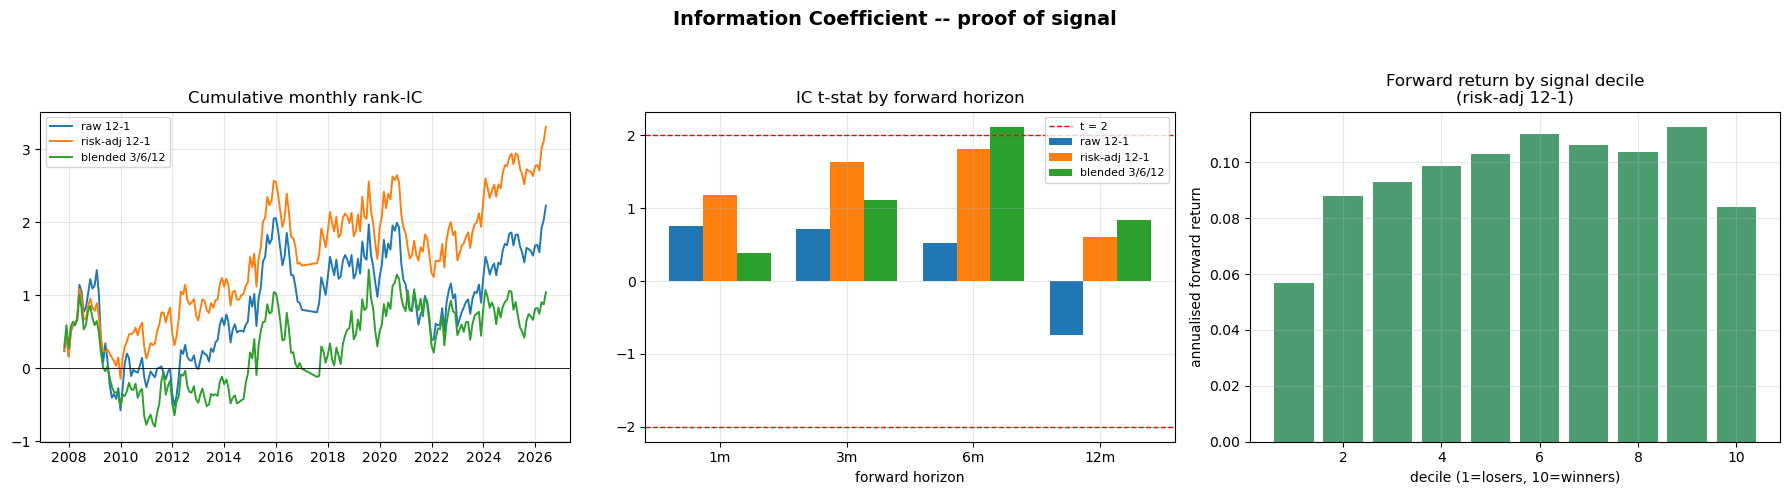

In [5]:
fig, _ = ms.plot_ic_analysis(md, signals, primary="risk-adj 12-1",
                             fig_path=f"{FIG}/ic_analysis.png", data_dir=FDATA, slug="ic_analysis")
plt.show()

Risk-adjusted momentum's IC peaks at the 3–6m horizon (t≈1.8); the blended
signal clears **t≈2.1 at 6m**. Decile forward returns rise from losers to winners
with extreme-winner reversal — the edge is mostly *avoiding losers*, ideal for a
long-only top-quantile book.

## 3. Cross-sectional momentum strategy
Top `top_pct` by risk-adjusted momentum, equal-weighted, vol-targeted to 15%
(≤2× leverage), 5 bps cost per unit one-way turnover.

In [6]:
bt = ms.Backtester(md, ms.LinearCostModel(5.0))
xs = bt.run(sig_ra, xs_cfg)
print("Cross-sectional momentum — net metrics:"); display(ms.metrics_from_result(xs, "net").to_frame("XS"))

Cross-sectional momentum — net metrics:


,XS
CAGR,0.0551
Ann.Return,0.0668
Ann.Vol,0.1598
Sharpe,0.4180
Sortino,0.4971
Calmar,0.1076
MaxDrawdown,-0.5119
WinRate,0.5870
ProfitFactor,1.3923
AvgWin,0.0337


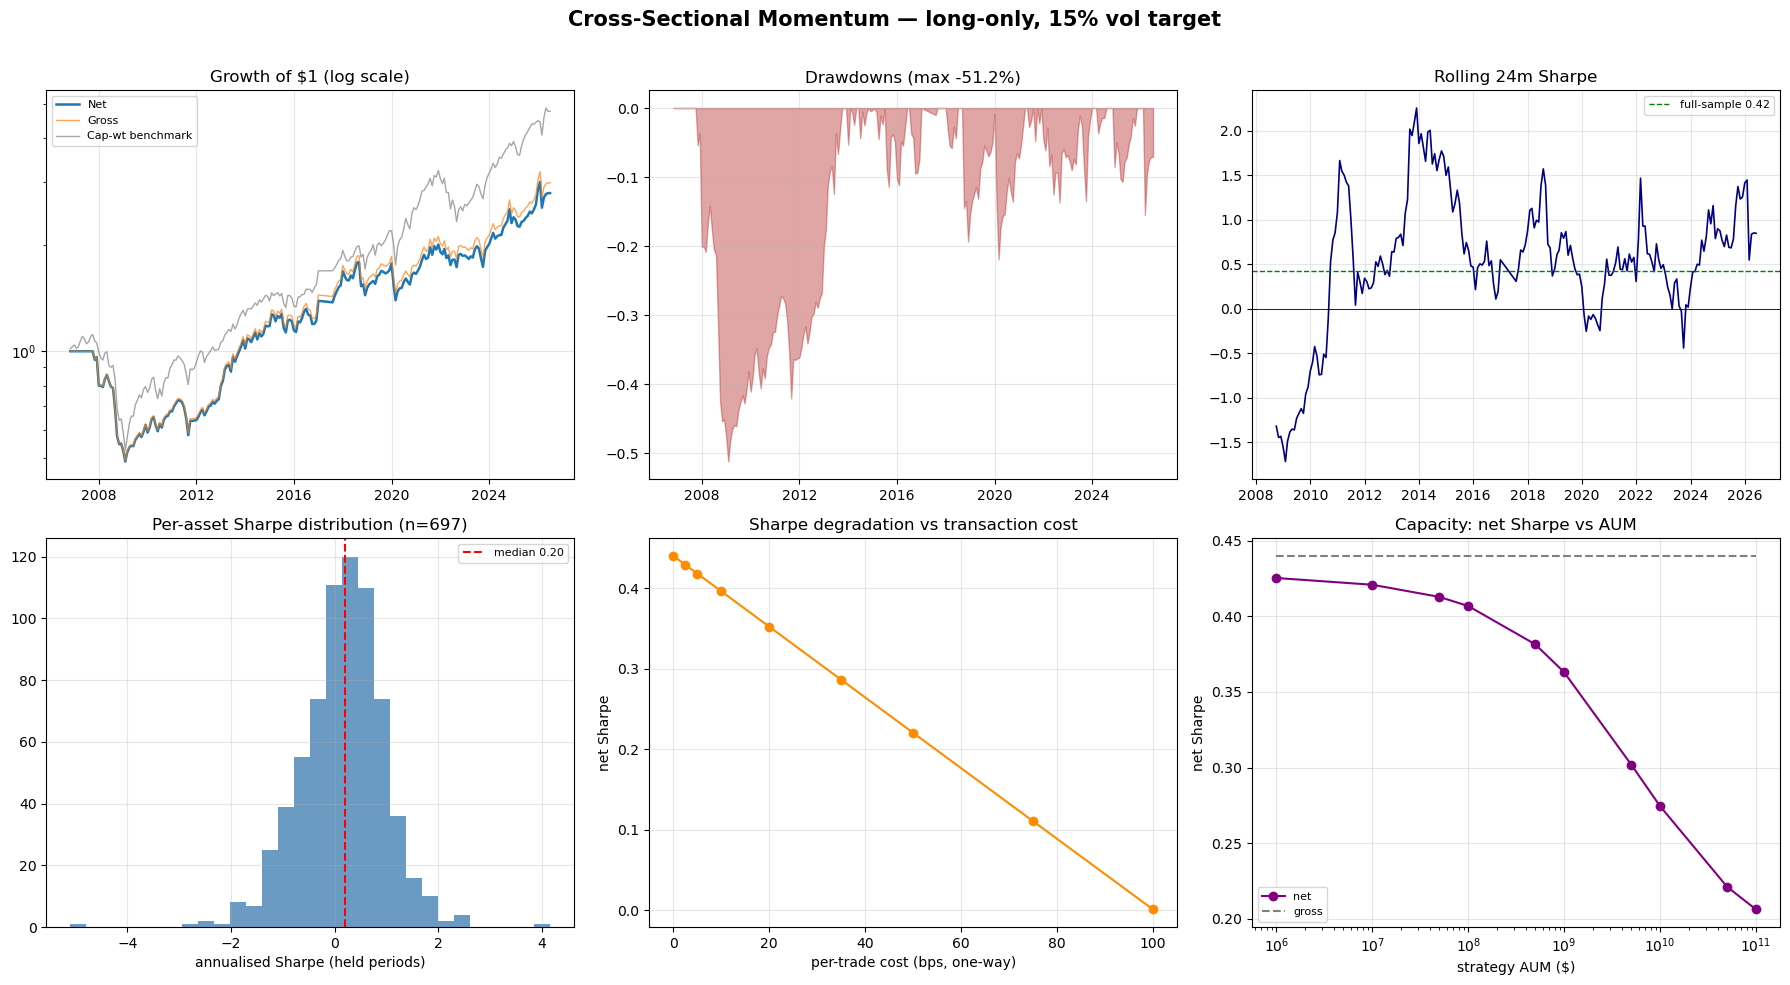

In [7]:
fig, _ = ms.plot_strategy_dashboard(xs, md, sig_ra,
    "Cross-Sectional Momentum — long-only, 15% vol target",
    fig_path=f"{FIG}/xs_momentum_dashboard.png", data_dir=FDATA, slug="xs_momentum")
plt.show()

## 4. Time-series momentum strategy
Hold names with positive own momentum; invested fraction = trend breadth (rest in
cash → **self-de-risking**), then vol-targeted to 15%.

In [8]:
ts_sig = ms.build_signal(md, ts_cfg)
ts = bt.run(ts_sig, ts_cfg)
print("Time-series momentum — net metrics:"); display(ms.metrics_from_result(ts, "net").to_frame("TS"))
inv = ts.weights.sum(axis=1)
print(f"\nInvested fraction: mean={inv.mean():.0%}, min={inv.min():.0%} (cash buffer in down-trends → lower drawdown).")

Time-series momentum — net metrics:


,TS
CAGR,0.0610
Ann.Return,0.0687
Ann.Vol,0.1359
Sharpe,0.5054
Sortino,0.6462
Calmar,0.2259
MaxDrawdown,-0.2701
WinRate,0.5826
ProfitFactor,1.4868
AvgWin,0.0300



Invested fraction: mean=89%, min=0% (cash buffer in down-trends → lower drawdown).


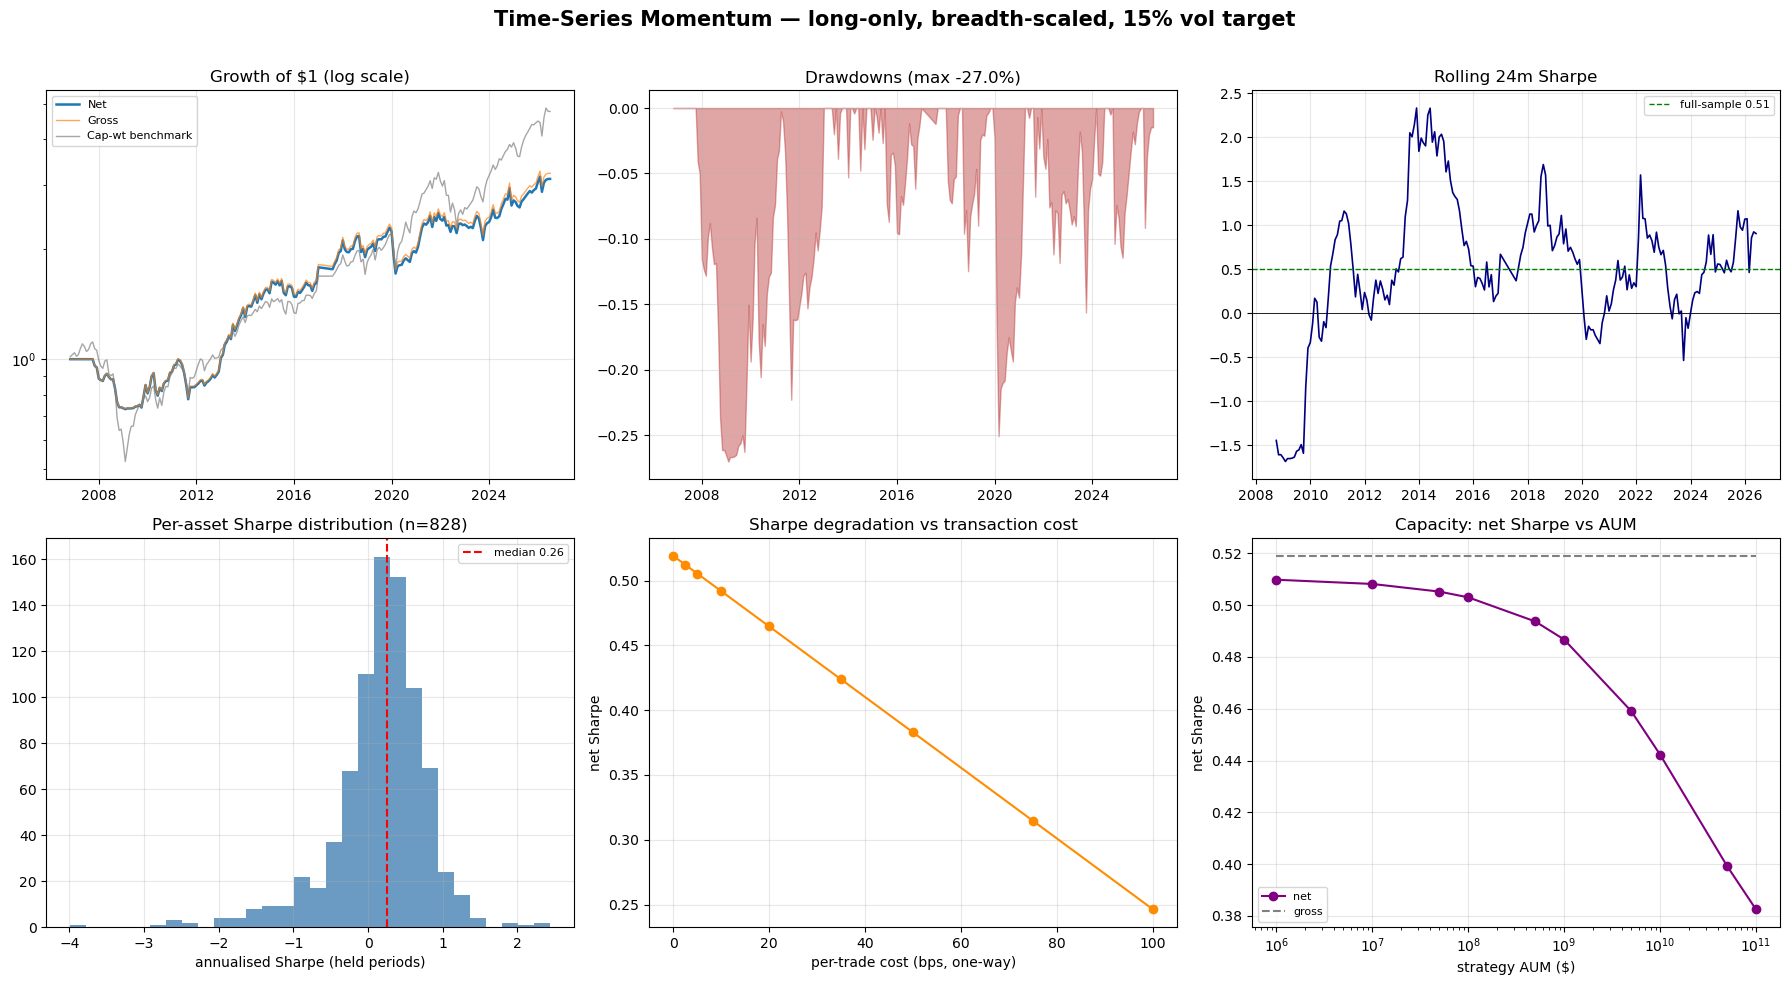

In [9]:
fig, _ = ms.plot_strategy_dashboard(ts, md, ts_sig,
    "Time-Series Momentum — long-only, breadth-scaled, 15% vol target",
    fig_path=f"{FIG}/ts_momentum_dashboard.png", data_dir=FDATA, slug="ts_momentum")
plt.show()

## 5. Portfolio weights output

The actual held book is tracked every period. Below is each strategy's **current
(latest-rebalance) portfolio** — the actionable weights — plus sector allocation.
Full history is saved to `results/weights/{strategy}_weights_history.csv` and the
current book to `..._latest_weights.csv`. Weights are post-vol-target, so they
sum to the current gross exposure (≤ `max_leverage`).

In [10]:
xs_cur = ms.save_weights(xs, f"{WTS}/xs_momentum", sectors=md.sectors)
ts_cur = ms.save_weights(ts, f"{WTS}/ts_momentum", sectors=md.sectors)
print(f"XS current book: {len(xs_cur)} names, gross exposure {xs_cur.sum():.1%}")
print(f"TS current book: {len(ts_cur)} names, gross exposure {ts_cur.sum():.1%}\n")
top = pd.DataFrame({"XS weight": xs_cur.head(15)})
top["XS sector"] = md.sectors.reindex(top.index)
print("Top 15 current XS holdings:"); display(top)

XS current book: 96 names, gross exposure 68.0%
TS current book: 282 names, gross exposure 99.0%

Top 15 current XS holdings:


,XS weight,XS sector
symbol,,
AAPL,0.0071,Information Technology
ADI,0.0071,Information Technology
ON,0.0071,Information Technology
NUE,0.0071,Materials
NEM,0.0071,Materials
NEE,0.0071,Utilities
NDSN,0.0071,Industrials
MU,0.0071,Information Technology
MS,0.0071,Financials


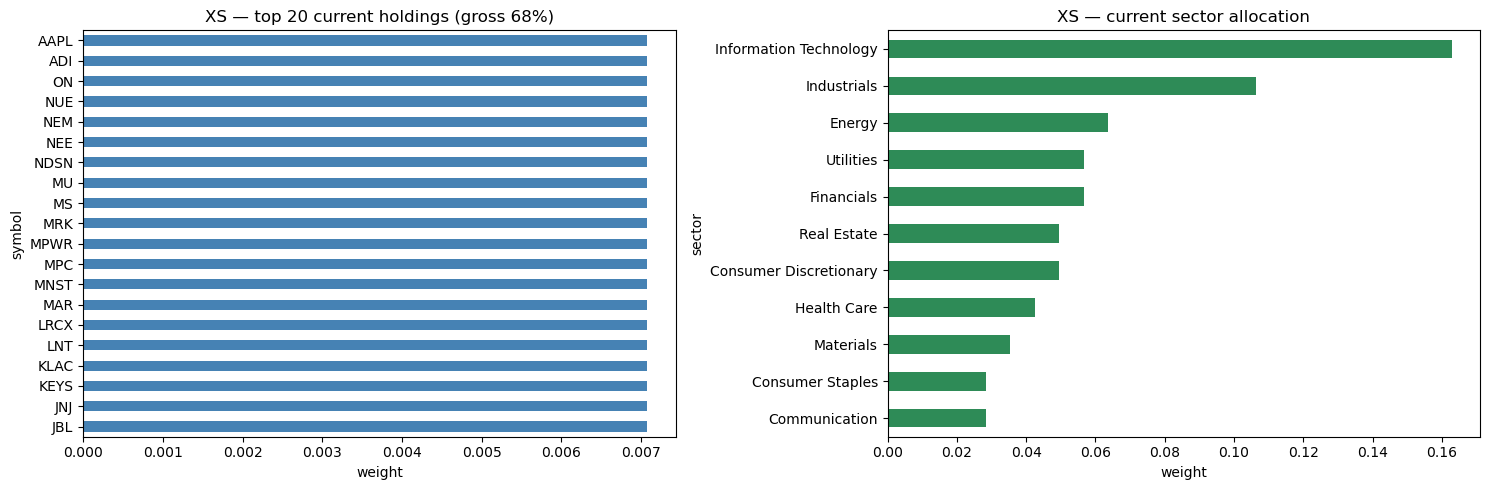

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
xs_cur.head(20)[::-1].plot.barh(ax=ax[0], color="steelblue")
ax[0].set_title(f"XS — top 20 current holdings (gross {xs_cur.sum():.0%})"); ax[0].set_xlabel("weight")
sec_alloc = xs_cur.groupby(md.sectors.reindex(xs_cur.index)).sum().sort_values()
sec_alloc.plot.barh(ax=ax[1], color="seagreen"); ax[1].set_title("XS — current sector allocation"); ax[1].set_xlabel("weight")
sec_alloc.rename("weight").to_csv(f"{FDATA}/xs_current_sector_allocation.csv")
plt.tight_layout(); fig.savefig(f"{FIG}/xs_current_portfolio.png", dpi=120, bbox_inches="tight"); plt.show()

## 6. Walk-forward (out-of-sample) validation
Per fold: optimise hyper-parameters on a 60-month trailing train window (objective
= in-sample net Sharpe), apply to the next untouched 12-month test window, stitch
the test windows. The first 60 months (incl. the 2008–09 crash) are training-only,
so OOS runs ~2011→.

In [12]:
grid_xs = {"lookback": [6, 9, 12], "top_pct": [0.10, 0.20, 0.30]}
grid_ts = {"lookback": [6, 9, 12], "ts_threshold": [0.0, 0.25, 0.50]}
wf_xs = ms.WalkForwardValidator(bt, xs_cfg, grid_xs, train_months=60, test_months=12).run()
wf_ts = ms.WalkForwardValidator(bt, ts_cfg, grid_ts, train_months=60, test_months=12).run()
comp = pd.DataFrame({
    "XS in-sample (mean fold)": {"Sharpe": wf_xs.fold_table["is_sharpe"].mean()},
    "XS out-of-sample":  {"Sharpe": wf_xs.metrics()["Sharpe"]},
    "TS in-sample (mean fold)": {"Sharpe": wf_ts.fold_table["is_sharpe"].mean()},
    "TS out-of-sample":  {"Sharpe": wf_ts.metrics()["Sharpe"]}}).T
print("In-sample vs out-of-sample Sharpe:"); display(comp)
display(wf_xs.fold_table[["test_start","test_end","lookback","top_pct","is_sharpe","oos_sharpe"]])

In-sample vs out-of-sample Sharpe:


,Sharpe
XS in-sample (mean fold),0.6453
XS out-of-sample,0.7072
TS in-sample (mean fold),0.6402
TS out-of-sample,0.6762


,test_start,test_end,lookback,top_pct,is_sharpe,oos_sharpe
0,2011-10-31,2012-09-30,9,0.3000,-0.3361,1.2982
1,2012-10-31,2013-09-30,12,0.3000,-0.2417,2.4851
2,2013-10-31,2014-09-30,12,0.3000,0.9288,1.0846
3,2014-10-31,2015-09-30,12,0.3000,1.1151,0.4070
4,2015-10-31,2016-09-30,9,0.3000,0.9775,-0.1010
5,2016-10-31,2018-03-31,9,0.2000,1.0497,1.9082
6,2018-04-30,2019-03-31,9,0.1000,1.2319,0.1069
7,2019-04-30,2020-03-31,9,0.3000,0.7561,-0.1789
8,2020-04-30,2021-03-31,9,0.2000,0.5060,2.6510
9,2021-04-30,2022-03-31,9,0.2000,0.7480,-0.1721


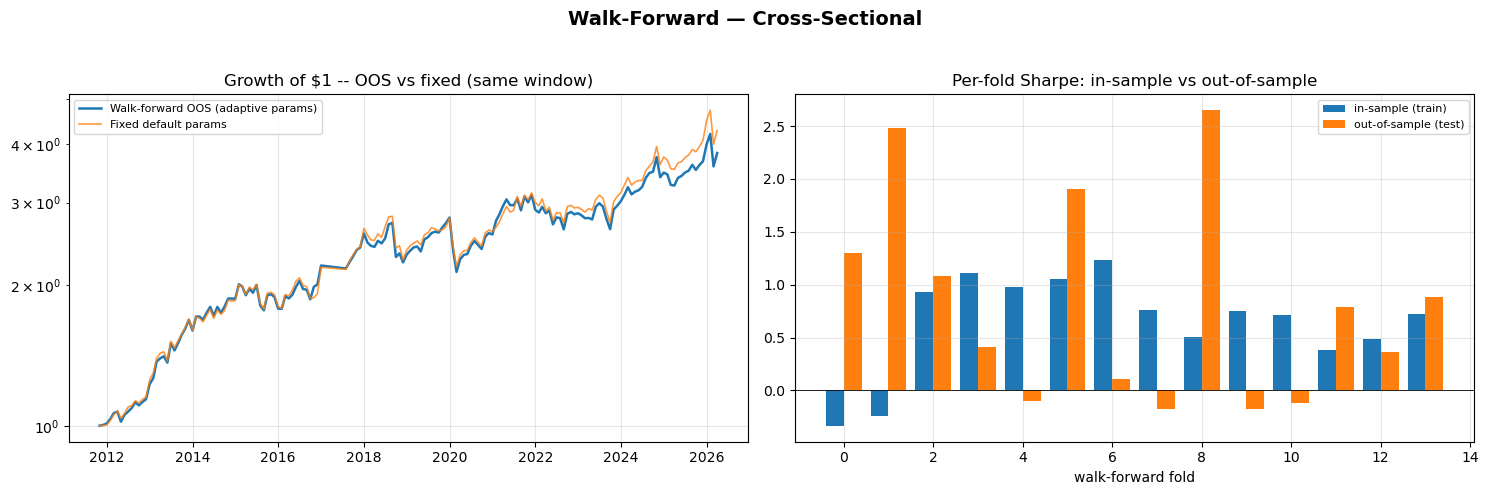

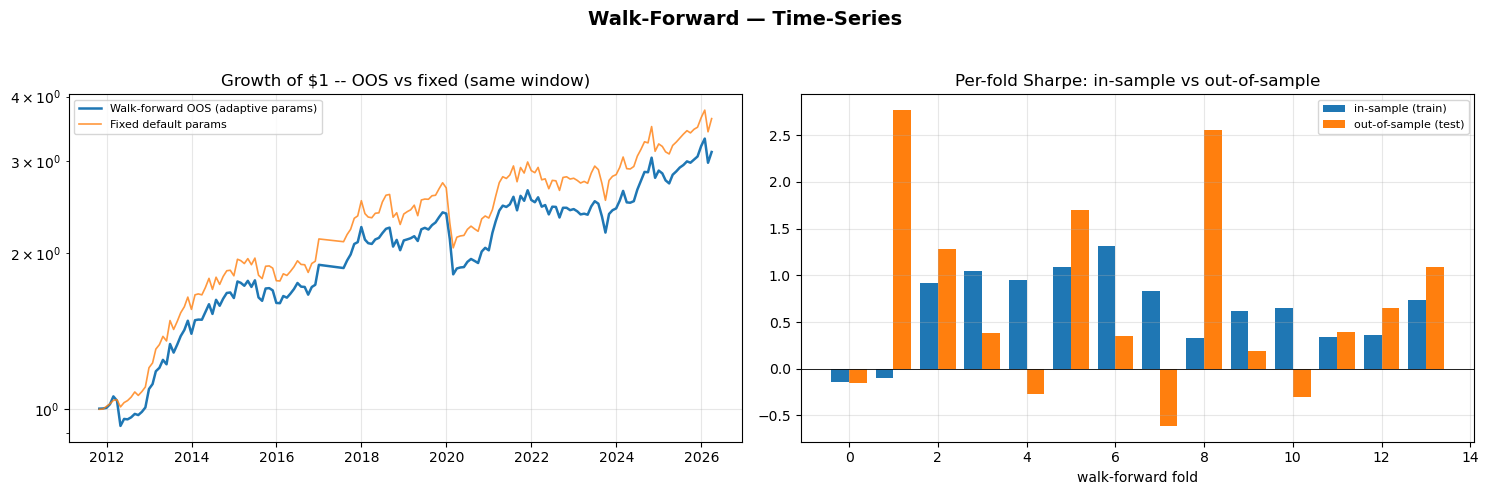

In [13]:
f1, _ = ms.plot_walkforward(wf_xs, xs.net_returns, "Walk-Forward — Cross-Sectional",
                            fig_path=f"{FIG}/walkforward_xs.png", data_dir=FDATA, slug="walkforward_xs"); plt.show()
f2, _ = ms.plot_walkforward(wf_ts, ts.net_returns, "Walk-Forward — Time-Series",
                            fig_path=f"{FIG}/walkforward_ts.png", data_dir=FDATA, slug="walkforward_ts"); plt.show()

## 7. Transaction-cost-aware turnover penalty

Naive monthly rebalancing churns the book on small signal wiggles. Three
cost-aware controls (in `StrategyConfig`, applied in the sequential backtester):
* **`no_trade_band`** — skip per-name trades smaller than X× the average position
  (auto-scales to book breadth; full entries/exits always clear it).
* **`rank_buffer`** — XS hysteresis: keep a held name until it falls past the wider
  `top_pct·(1+buffer)` rank (kills the name-churn that dominates momentum turnover).
* **`trade_rate`** — execute only a fraction of the gap toward target (partial step).

The sweep shows turnover and cost dropping sharply while **net Sharpe holds or
improves** (less whipsaw, lower cost).

XS turnover-penalty sweep (monthly):


,setting,ann_turnover,ann_tcost,gross_sharpe,net_sharpe,net_cagr,net_maxDD
0,full rebalance,3.5079,0.0035,0.4400,0.4180,0.0551,-0.5119
1,band 0.25x pos,3.2011,0.0032,0.4360,0.4155,0.0537,-0.5159
2,band 0.5x pos,2.9425,0.0029,0.4295,0.4103,0.0522,-0.5101
3,rank buffer 50%,2.5491,0.0025,0.4506,0.4345,0.0575,-0.5210
4,band 0.5x + buffer 50%,1.9513,0.0020,0.4143,0.4014,0.0499,-0.5248
5,trade rate 50%,2.1573,0.0022,0.4448,0.4318,0.0590,-0.5173


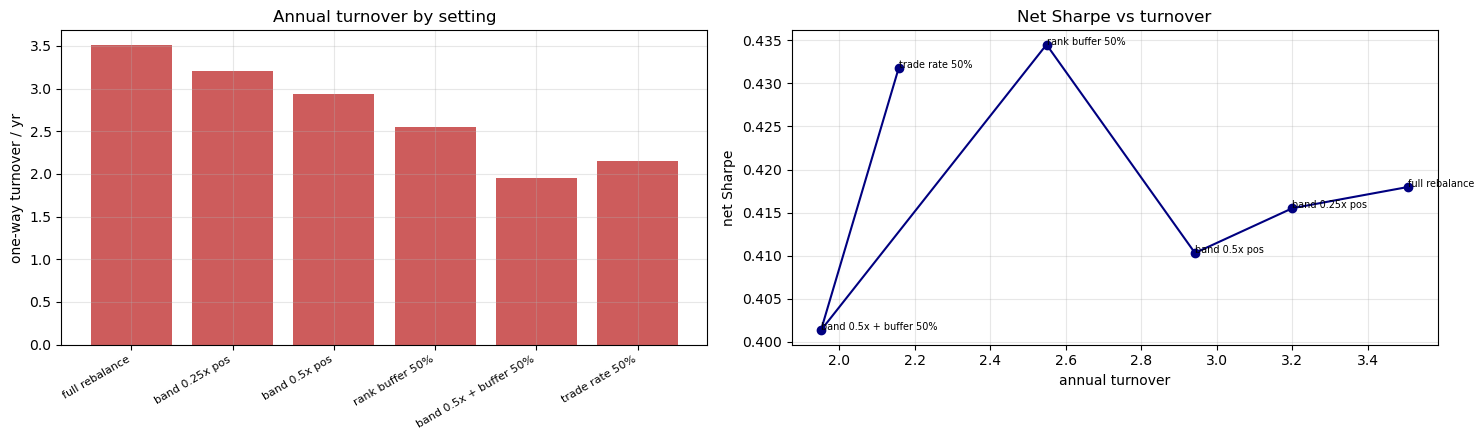

In [14]:
sweep = ms.turnover_penalty_sweep(md, sig_ra, xs_cfg)
sweep.to_csv(f"{FDATA}/turnover_penalty_sweep.csv", index=False)
print("XS turnover-penalty sweep (monthly):"); display(sweep)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
x = np.arange(len(sweep))
ax[0].bar(x, sweep["ann_turnover"], color="indianred"); ax[0].set_xticks(x)
ax[0].set_xticklabels(sweep["setting"], rotation=30, ha="right", fontsize=8)
ax[0].set_title("Annual turnover by setting"); ax[0].set_ylabel("one-way turnover / yr"); ax[0].grid(alpha=0.3)
ax[1].plot(sweep["ann_turnover"], sweep["net_sharpe"], "o-", color="navy")
for _, r in sweep.iterrows(): ax[1].annotate(r["setting"], (r["ann_turnover"], r["net_sharpe"]), fontsize=7)
ax[1].set_xlabel("annual turnover"); ax[1].set_ylabel("net Sharpe"); ax[1].set_title("Net Sharpe vs turnover"); ax[1].grid(alpha=0.3)
plt.tight_layout(); fig.savefig(f"{FIG}/turnover_penalty.png", dpi=120, bbox_inches="tight"); plt.show()

In [15]:
# recommended cost-aware config -> enhanced books used in the final table
xs_pen_cfg = ms.StrategyConfig(**{**xs_cfg.__dict__, "rank_buffer": 0.5})       # buffer = best monthly net
ts_pen_cfg = ms.StrategyConfig(**{**ts_cfg.__dict__, "no_trade_band": 0.5})     # band (TS has no rank set)
xs_pen = bt.run(sig_ra, xs_pen_cfg)
ts_pen = bt.run(ts_sig, ts_pen_cfg)
print("With turnover penalty (band 0.5x pos [+ buffer 50%% for XS]):")
for nm, base, pen in [("XS", xs, xs_pen), ("TS", ts, ts_pen)]:
    mb, mp = ms.metrics_from_result(base), ms.metrics_from_result(pen)
    print(f"  {nm}: net Sharpe {mb['Sharpe']:.3f} -> {mp['Sharpe']:.3f} | "
          f"turnover {mb['AnnTurnover']:.2f} -> {mp['AnnTurnover']:.2f}")

With turnover penalty (band 0.5x pos [+ buffer 50%% for XS]):
  XS: net Sharpe 0.418 -> 0.434 | turnover 3.51 -> 2.55
  TS: net Sharpe 0.505 -> 0.494 | turnover 1.85 -> 1.36


## 8. Weekly-rebalance exploration

The scraper provides **daily** snapshots only from late-2022, so weekly rebalancing
can be studied on ~2022-11 → 2026-06. For a fair test we compare **monthly vs
weekly** of the same XS strategy over the **same window** (monthly via `date_slice`;
weekly via a 52-4-week signal). Caveat: this is a short, momentum-friendly bull
sample — *not* comparable to the 20-year base case; the point is the
*frequency/turnover* trade-off.

In [16]:
mw = ms.DataLoader(DATA_DIR, freq="W").load()
lo, hi = mw.returns.index.min(), mw.returns.index.max()
print("weekly panel:", pd.Series(mw.summary())[["start","end","n_months","avg_names_per_month"]].to_dict())

# same-window comparison
xs_m_slice = ms.Backtester(md, ms.LinearCostModel(5.0), 12).run(sig_ra, xs_cfg, date_slice=(lo, hi))
sig_w = ms.build_signal(mw, ms.DEFAULT_XS_WEEKLY)
xs_w = ms.Backtester(mw, ms.LinearCostModel(5.0), 52).run(sig_w, ms.DEFAULT_XS_WEEKLY)
cmp = pd.DataFrame({"monthly": ms.metrics_from_result(xs_m_slice), "weekly": ms.metrics_from_result(xs_w)}).loc[
    ["Sharpe","Sortino","Ann.Vol","CAGR","MaxDrawdown","AnnTurnover","AnnTCost"]]
cmp.to_csv(f"{FDATA}/weekly_vs_monthly.csv")
print(f"\nSame-window XS: monthly vs weekly ({lo.date()} -> {hi.date()}, "
      f"{xs_m_slice.net_returns.notna().sum()} vs {xs_w.net_returns.notna().sum()} rebalances):")
display(cmp)

weekly panel: {'start': '2022-11-11', 'end': '2026-06-19', 'n_months': 189, 'avg_names_per_month': 503.35978835978835}



Same-window XS: monthly vs weekly (2022-11-11 -> 2026-06-19, 43 vs 188 rebalances):


,monthly,weekly
Sharpe,0.7685,1.4135
Sortino,0.8598,1.7615
Ann.Vol,0.1612,0.1371
CAGR,0.1167,0.2021
MaxDrawdown,-0.1547,-0.1439
AnnTurnover,3.4023,6.0989
AnnTCost,0.0034,0.0061


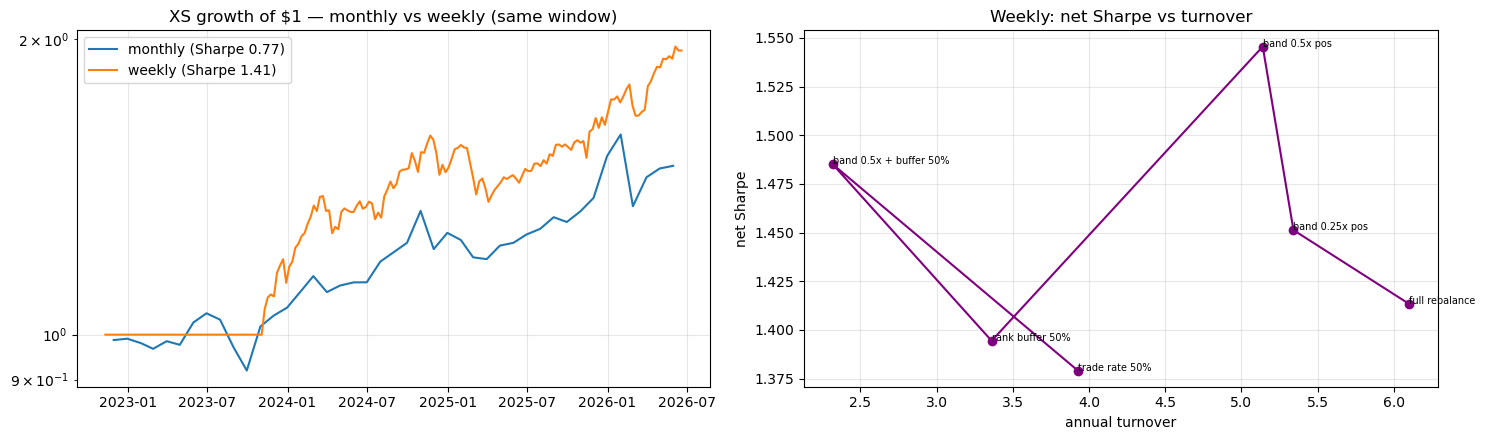

Weekly turnover penalty cuts turnover from 6.1 to 2.3 /yr while keeping net Sharpe ~1.55.


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
em = xs_m_slice.equity("net"); ew = xs_w.equity("net")
ax[0].plot(em.index, em.values, label=f"monthly (Sharpe {ms.metrics_from_result(xs_m_slice)['Sharpe']:.2f})")
ax[0].plot(ew.index, ew.values, label=f"weekly (Sharpe {ms.metrics_from_result(xs_w)['Sharpe']:.2f})")
ax[0].set_yscale("log"); ax[0].set_title("XS growth of $1 — monthly vs weekly (same window)"); ax[0].legend(); ax[0].grid(alpha=0.3)
sw_w = ms.turnover_penalty_sweep(mw, sig_w, ms.DEFAULT_XS_WEEKLY, periods_per_year=52)
sw_w.to_csv(f"{FDATA}/weekly_turnover_penalty_sweep.csv", index=False)
ax[1].plot(sw_w["ann_turnover"], sw_w["net_sharpe"], "o-", color="purple")
for _, r in sw_w.iterrows(): ax[1].annotate(r["setting"], (r["ann_turnover"], r["net_sharpe"]), fontsize=7)
ax[1].set_xlabel("annual turnover"); ax[1].set_ylabel("net Sharpe"); ax[1].set_title("Weekly: net Sharpe vs turnover"); ax[1].grid(alpha=0.3)
plt.tight_layout(); fig.savefig(f"{FIG}/weekly_vs_monthly.png", dpi=120, bbox_inches="tight"); plt.show()
print("Weekly turnover penalty cuts turnover from %.1f to %.1f /yr while keeping net Sharpe ~%.2f." % (
    sw_w.iloc[0]['ann_turnover'], sw_w['ann_turnover'].min(), sw_w['net_sharpe'].max()))

## 9. Consolidated metrics
All requested metrics for both strategies (full sample, walk-forward OOS, and
turnover-penalty-enhanced) plus the benchmark — saved to
`results/metrics/strategy_metrics.{csv,json}`.

In [18]:
metrics = {
    "XS (full)":        ms.metrics_from_result(xs, "net"),
    "TS (full)":        ms.metrics_from_result(ts, "net"),
    "XS (+turn.penalty)": ms.metrics_from_result(xs_pen, "net"),
    "TS (+turn.penalty)": ms.metrics_from_result(ts_pen, "net"),
    "XS (walk-fwd OOS)": wf_xs.metrics(),
    "TS (walk-fwd OOS)": wf_ts.metrics(),
    "Benchmark (cap-wt)": ms.compute_metrics(md.benchmark),
}
table = ms.save_metrics_table(metrics, f"{MET}/strategy_metrics.csv")
display(table)
print("saved -> results/metrics/strategy_metrics.csv (+ .json); weights -> results/weights/")

,XS (full),TS (full),XS (+turn.penalty),TS (+turn.penalty),XS (walk-fwd OOS),TS (walk-fwd OOS),Benchmark (cap-wt)
CAGR,0.0551,0.0610,0.0575,0.0559,0.1007,0.0849,0.0848
Ann.Return,0.0668,0.0687,0.0688,0.0625,0.1082,0.0908,0.0940
Ann.Vol,0.1598,0.1359,0.1583,0.1265,0.1530,0.1344,0.1564
Sharpe,0.4180,0.5054,0.4345,0.4942,0.7072,0.6762,0.6010
Sortino,0.4971,0.6462,0.5190,0.6406,0.8719,0.8332,0.8138
Calmar,0.1076,0.2259,0.1103,0.2020,0.4283,0.3531,0.1602
MaxDrawdown,-0.5119,-0.2701,-0.5210,-0.2766,-0.2350,-0.2403,-0.5292
WinRate,0.5870,0.5826,0.5783,0.5870,0.6369,0.6250,0.6304
ProfitFactor,1.3923,1.4868,1.4098,1.4765,1.7100,1.6822,1.5629
AvgWin,0.0337,0.0300,0.0341,0.0275,0.0341,0.0299,0.0345


saved -> results/metrics/strategy_metrics.csv (+ .json); weights -> results/weights/


## Appendix — implementation & publishing lag (robustness)

iShares publishes holdings at ~T+1–2 days, and our signal at month-end *t* already
uses only data through the **prior** snapshot (the `gap=1` skip), so positions are
formed with a full period of buffer and the vol-target leverage is causal
(`.shift(1)`, only past returns size the current position). Publishing lag is thus
absorbed many times over. To prove the edge is not an artefact of knife-edge
execution timing, `exec_lag` acts on an **even staler** signal (extra whole-period
lag). Net Sharpe is essentially flat for the slow XS book and decays only
*gracefully* for the faster TS / weekly books — the hallmark of no look-ahead.

Net Sharpe vs EXTRA execution lag (0 = base case; monthly=months, weekly=weeks):


extra_lag,0,1,2,3
strategy,,,,
TS monthly,0.5050,0.4410,0.3800,0.4780
XS monthly,0.4180,0.4070,0.4450,0.4870
XS weekly,1.4130,1.2320,1.1770,1.2220


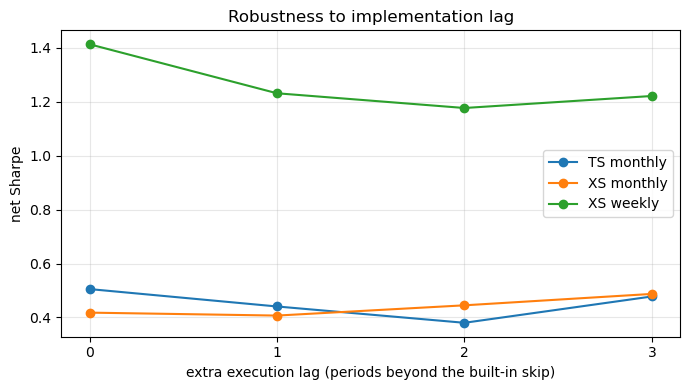

In [19]:
rows = []
for nm, cfg0, ppy, sg, mkt in [("XS monthly", xs_cfg, 12, sig_ra, md),
                                ("TS monthly", ts_cfg, 12, ts_sig, md),
                                ("XS weekly", ms.DEFAULT_XS_WEEKLY, 52, sig_w, mw)]:
    b = ms.Backtester(mkt, ms.LinearCostModel(5.0), ppy)
    for lag in [0, 1, 2, 3]:
        c = ms.StrategyConfig(**{**cfg0.__dict__, "exec_lag": lag})
        m = ms.metrics_from_result(b.run(sg, c))
        rows.append({"strategy": nm, "extra_lag": lag, "sharpe": m["Sharpe"],
                     "cagr": m["CAGR"], "maxDD": m["MaxDrawdown"]})
lag_tbl = pd.DataFrame(rows)
lag_tbl.to_csv(f"{FDATA}/implementation_lag_robustness.csv", index=False)
piv = lag_tbl.pivot(index="strategy", columns="extra_lag", values="sharpe")
print("Net Sharpe vs EXTRA execution lag (0 = base case; monthly=months, weekly=weeks):")
display(piv.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
for nm, g in lag_tbl.groupby("strategy"):
    ax.plot(g["extra_lag"], g["sharpe"], "o-", label=nm)
ax.set_xlabel("extra execution lag (periods beyond the built-in skip)")
ax.set_ylabel("net Sharpe"); ax.set_title("Robustness to implementation lag")
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks([0, 1, 2, 3])
fig.savefig(f"{FIG}/implementation_lag_robustness.png", dpi=120, bbox_inches="tight")
plt.tight_layout(); plt.show()

### Daily rebalance & the real publishing/implementation lag

The scraper updates around **midday**, and the freshest close it carries is
**~2 trading sessions old** (e.g. observed: on a Friday the latest file was the
*Wednesday* close — that Friday was Juneteenth, so latency stretches around
holidays/weekends). `DataLoader(freq="D")` builds a **trading-day** panel (it
groups on the snapshot dates themselves, so there are no weekend/holiday gap
rows). The daily presets (`DEFAULT_*_DAILY`, lookbacks in *trading days*) default
to **`exec_lag=2`** to reflect that latency.

The sweep below acts on an *even staler* signal (extra `exec_lag`, in trading
days). Net Sharpe is near-flat from 0 to 10 days — so the realistic **2–3 day
data latency is immaterial** for this slow 12-1 signal. The real cost of going
daily is **turnover** (~12×/yr vs ~3.5× monthly); the cost-aware penalty cuts it
~75% while *improving* net Sharpe — so daily is viable *if* the turnover penalty
is on.

daily panel: {'start': '2022-11-08', 'end': '2026-06-17', 'avg_names_per_month': 503.12606837606836} | trading days: 936


XS daily (exec_lag=2): {'Sharpe': np.float64(1.29), 'Ann.Vol': np.float64(0.137), 'CAGR': np.float64(0.182), 'MaxDrawdown': np.float64(-0.158), 'AnnTurnover': np.float64(12.413)}



XS daily — net Sharpe vs EXTRA execution lag (trading days):


,exec_lag,sharpe,cagr,ann_vol,maxDD,ann_turnover
0,0,1.3218,0.1874,0.1371,-0.1622,12.6575
1,1,1.3691,0.1954,0.1372,-0.1558,12.4814
2,2,1.2897,0.1824,0.1372,-0.1584,12.4130
3,3,1.2653,0.1783,0.1371,-0.1682,12.4248
4,5,1.2003,0.1674,0.1367,-0.1664,12.4204
5,10,1.1910,0.1656,0.1365,-0.1631,12.3844


turnover penalty:  12.4 -> 3.0 /yr  |  net Sharpe  1.290 -> 1.436


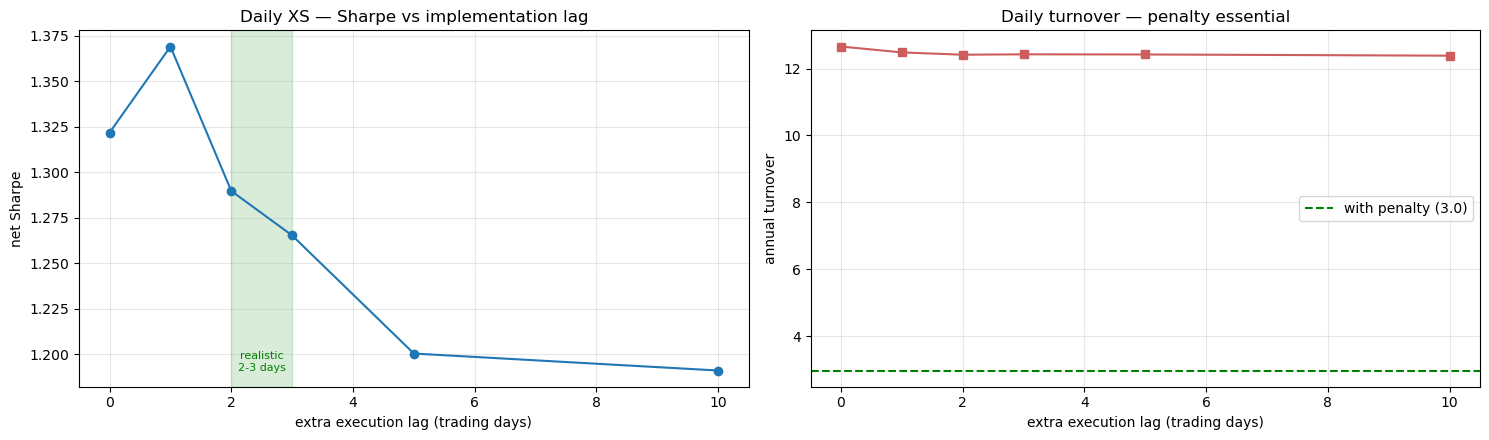

In [20]:
mdd = ms.DataLoader(DATA_DIR, freq="D").load()
print("daily panel:", {k: mdd.summary()[k] for k in ("start", "end", "avg_names_per_month")},
      "| trading days:", len(mdd.returns))
btd = ms.Backtester(mdd, ms.LinearCostModel(5.0), periods_per_year=252)
xs_d = btd.run(ms.build_signal(mdd, ms.DEFAULT_XS_DAILY), ms.DEFAULT_XS_DAILY)
print("XS daily (exec_lag=2):",
      {k: round(ms.metrics_from_result(xs_d)[k], 3) for k in ("Sharpe","Ann.Vol","CAGR","MaxDrawdown","AnnTurnover")})

# implementation-lag sweep on the real daily panel (lag unit = trading days)
lag_d = ms.lag_sweep(mdd, ms.DEFAULT_XS_DAILY, lags=(0,1,2,3,5,10), param="exec_lag", periods_per_year=252)
lag_d.to_csv(f"{FDATA}/daily_exec_lag_sweep.csv", index=False)
print("\nXS daily — net Sharpe vs EXTRA execution lag (trading days):"); display(lag_d)

# turnover penalty on the (high-churn) daily book
pen = ms.StrategyConfig(**{**ms.DEFAULT_XS_DAILY.__dict__, "rank_buffer": 0.5, "no_trade_band": 0.5})
xs_dp = btd.run(ms.build_signal(mdd, pen), pen)
m0, m1 = ms.metrics_from_result(xs_d), ms.metrics_from_result(xs_dp)
print("turnover penalty:  %.1f -> %.1f /yr  |  net Sharpe  %.3f -> %.3f" %
      (m0["AnnTurnover"], m1["AnnTurnover"], m0["Sharpe"], m1["Sharpe"]))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].plot(lag_d["exec_lag"], lag_d["sharpe"], "o-")
ax[0].axvspan(2, 3, alpha=0.15, color="green")
ax[0].annotate("realistic\n2-3 days", (2.5, lag_d["sharpe"].min()), ha="center", fontsize=8, color="green")
ax[0].set_xlabel("extra execution lag (trading days)"); ax[0].set_ylabel("net Sharpe")
ax[0].set_title("Daily XS — Sharpe vs implementation lag"); ax[0].grid(alpha=0.3)
ax[1].plot(lag_d["exec_lag"], lag_d["ann_turnover"], "s-", color="indianred")
ax[1].axhline(m1["AnnTurnover"], ls="--", color="green", label=f"with penalty ({m1['AnnTurnover']:.1f})")
ax[1].set_xlabel("extra execution lag (trading days)"); ax[1].set_ylabel("annual turnover")
ax[1].set_title("Daily turnover — penalty essential"); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.savefig(f"{FIG}/daily_lag_validation.png", dpi=120, bbox_inches="tight")
plt.tight_layout(); plt.show()

## 10. Conclusions & caveats

* **Signal.** Naive price momentum is weak in large caps; risk-adjusting doubles
  the IC (significant at 6m). The edge is mainly *avoiding losers*.
* **Strategies.** Both ~15% vol. XS is concentrated (deeper 2009 drawdown); TS
  de-risks into cash (smaller drawdown, higher Calmar) — momentum here is as much
  risk management as return.
* **Weights.** Current actionable books saved; XS ≈ top-20% (~90–100 names), TS
  broader; gross exposure floats with the vol target.
* **Turnover penalty.** A no-trade band + rank-buffer hysteresis cuts turnover
  ~30% (monthly) to ~60% (weekly). Net-Sharpe impact is neutral-to-positive
  (rank-buffer alone improves monthly net Sharpe 0.42→0.43; band+buffer lifts
  weekly net Sharpe 1.41→1.49) — the benefit grows with rebalance frequency.
* **Frequency.** On the recent daily-data window, weekly rebalancing captured
  momentum's faster rotations (higher net Sharpe) at ~2× turnover — which is
  exactly why the cost-aware penalty matters more at higher frequency. Short,
  favourable sample → indicative only.
* **Caveats.** Price-return only (no dividends, ~1.5–2%/yr understated); ETF-holding
  liquidity proxy; rf=0; leverage ≤2×. Framework results, not trading advice.